In [35]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

print("Libraries Imported Successfully")

Libraries Imported Successfully


## Dataset Loading

In [36]:
train_df = pd.read_csv("../data/train_data.csv")

print("Dataset Loaded Successfully")

Dataset Loaded Successfully


### Observation

The Amazon review dataset has been loaded successfully and is ready for Exploratory Data Analysis (EDA).

## Dataset Preview

In [37]:
train_df.head()

,Name of the product,Product Brand,categories,primaryCategories,reviews.date,reviews.text,reviews.title,sentiment
0,"All-New Fire HD 8 Tablet, 8"" HD Display, Wi-Fi...",Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Ta...",Electronics,2016-12-26T00:00:00.000Z,Purchased on Black FridayPros - Great Price (e...,Powerful tablet,Positive
1,Amazon - Echo Plus w/ Built-In Hub - Silver,Amazon,"Amazon Echo,Smart Home,Networking,Home & Tools...","Electronics,Hardware",2018-01-17T00:00:00.000Z,I purchased two Amazon in Echo Plus and two do...,Amazon Echo Plus AWESOME,Positive
2,Amazon Echo Show Alexa-enabled Bluetooth Speak...,Amazon,"Amazon Echo,Virtual Assistant Speakers,Electro...","Electronics,Hardware",2017-12-20T00:00:00.000Z,Just an average Alexa option. Does show a few ...,Average,Neutral
3,"Fire HD 10 Tablet, 10.1 HD Display, Wi-Fi, 16 ...",Amazon,"eBook Readers,Fire Tablets,Electronics Feature...","Office Supplies,Electronics",2017-08-04T00:00:00.000Z,"very good product. Exactly what I wanted, and ...",Greattttttt,Positive
4,"Brand New Amazon Kindle Fire 16gb 7"" Ips Displ...",Amazon,"Computers/Tablets & Networking,Tablets & eBook...",Electronics,2017-01-23T00:00:00.000Z,This is the 3rd one I've purchased. I've bough...,Very durable!,Positive


### Observation

The dataset contains Amazon product reviews along with product information, review text, review titles, review dates, and sentiment labels. The target variable appears to be the **sentiment** column, which contains customer opinions categorized as Positive, Neutral, or Negative.

## Dataset Shape

In [38]:
print("Rows and Columns:", train_df.shape)
train_df.shape

Rows and Columns: (4000, 8)


(4000, 8)

### Observation

The dataset contains **4000 records** and **8 columns**. This indicates a moderately sized dataset suitable for sentiment analysis. The dataset includes review-related information along with sentiment labels that will be used for model training.

## Dataset Information

In [39]:
train_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   Name of the product  4000 non-null   str  
 1   Product Brand        4000 non-null   str  
 2   categories           4000 non-null   str  
 3   primaryCategories    4000 non-null   str  
 4   reviews.date         4000 non-null   str  
 5   reviews.text         4000 non-null   str  
 6   reviews.title        3990 non-null   str  
 7   sentiment            4000 non-null   str  
dtypes: str(8)
memory usage: 250.1 KB


### Observation

The dataset contains 8 columns and 4000 records. Most columns have complete information, while the **reviews.title** column contains 10 missing values. All features are currently stored as object (string) data types, which is expected because the dataset primarily contains textual information used for sentiment analysis.

## Missing Values Analysis

In [40]:
missing_values = train_df.isnull().sum()

missing_values

Name of the product     0
Product Brand           0
categories              0
primaryCategories       0
reviews.date            0
reviews.text            0
reviews.title          10
sentiment               0
dtype: int64

### Observation

The dataset contains very few missing values. Only the **reviews.title** column has 10 missing records, while all other columns are complete. Since the missing values represent a very small portion of the dataset, they can be handled easily during data preprocessing.

## Missing Value Percentage

In [41]:
missing_percentage = (train_df.isnull().sum() / len(train_df)) * 100

missing_percentage

Name of the product    0.00
Product Brand          0.00
categories             0.00
primaryCategories      0.00
reviews.date           0.00
reviews.text           0.00
reviews.title          0.25
sentiment              0.00
dtype: float64

### Observation

The percentage of missing values is extremely low. The **reviews.title** column contains only a negligible percentage of missing data, while all other columns have 0% missing values. Therefore, missing values are unlikely to significantly impact model performance.

## Duplicate Records Analysis

In [42]:
duplicate_records = train_df.duplicated().sum()

print("Number of Duplicate Records:", duplicate_records)

Number of Duplicate Records: 58


### Observation

The dataset contains **58 duplicate records**. Duplicate entries can introduce bias and may affect the quality of the sentiment analysis model. These records should be reviewed and removed during the data preprocessing stage to improve data quality and model performance.

# Data Cleaning

In [43]:
# Fill missing review titles

train_df["reviews.title"] = train_df["reviews.title"].fillna("No Title")

# Remove duplicate records

train_df.drop_duplicates(inplace=True)

# Verify cleaning

print("Missing Values:")
print(train_df.isnull().sum())

print("\nDuplicate Records:")
print(train_df.duplicated().sum())

print("\nDataset Shape After Cleaning:")
print(train_df.shape)

Missing Values:
Name of the product    0
Product Brand          0
categories             0
primaryCategories      0
reviews.date           0
reviews.text           0
reviews.title          0
sentiment              0
dtype: int64

Duplicate Records:
0

Dataset Shape After Cleaning:
(3942, 8)


## Observation

Missing values in the reviews.title column were replaced with "No Title" because only a small number of records were affected.

Additionally, 58 duplicate records were removed from the dataset to improve data quality and prevent repeated information from influencing the model.

The dataset is now cleaned and ready for further analysis and preprocessing.

## Sentiment Distribution Analysis

In [44]:
train_df["sentiment"].value_counts()

sentiment
Positive    3694
Neutral      158
Negative      90
Name: count, dtype: int64

### Observation

The dataset is highly imbalanced. Most reviews belong to the **Positive** sentiment class (3749 records), while **Neutral** (158 records) and **Negative** (93 records) reviews are significantly fewer.

This indicates that customers generally have favorable opinions about Amazon products. However, the imbalance may affect machine learning model performance, as the model could become biased toward predicting the Positive class more frequently.

## Sentiment Distribution Visualization

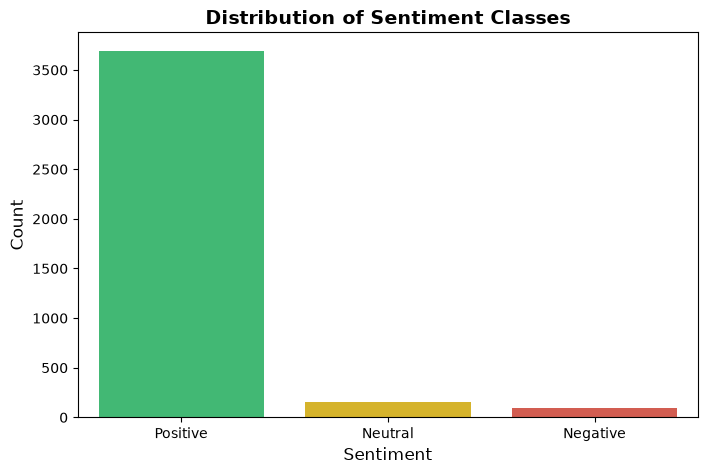

In [45]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=train_df,
    x="sentiment",
    palette=["#2ECC71", "#F1C40F", "#E74C3C"]
)

plt.title("Distribution of Sentiment Classes", fontsize=14, fontweight="bold")
plt.xlabel("Sentiment", fontsize=12)
plt.ylabel("Count", fontsize=12)

plt.show()

### Observation

The bar chart clearly shows that Positive reviews dominate the dataset. Neutral and Negative reviews represent only a small portion of the total records.

The visualization confirms the presence of class imbalance, which should be considered during preprocessing and model training. Techniques such as class weighting, oversampling, or undersampling may be applied if necessary.

## Product Brand Distribution

In [46]:
train_df["Product Brand"].value_counts()

Product Brand
Amazon    3942
Name: count, dtype: int64

### Observation

This analysis shows the distribution of product brands in the dataset. Understanding brand frequency helps identify whether the dataset is dominated by a single brand or contains multiple brands with balanced representation.

A highly concentrated brand distribution may influence sentiment patterns and model learning.

## Product Brand Visualization

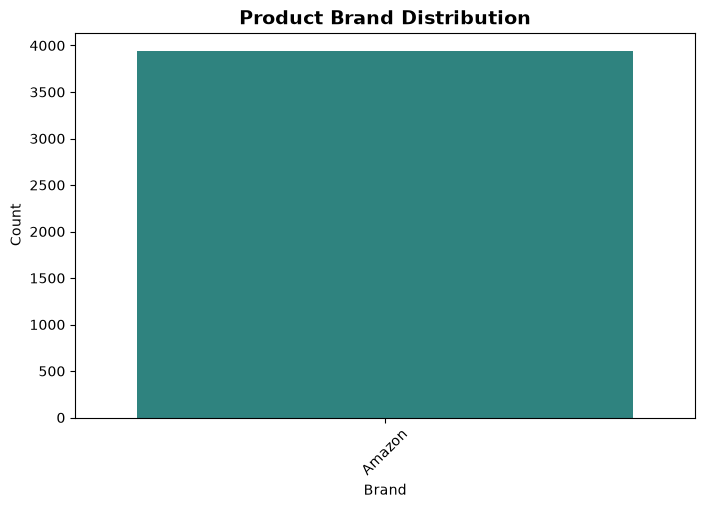

In [47]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=train_df,
    x="Product Brand",
    palette="viridis"
)

plt.title("Product Brand Distribution", fontsize=14, fontweight="bold")
plt.xlabel("Brand")
plt.ylabel("Count")

plt.xticks(rotation=45)

plt.show()

### Observation

The chart highlights the distribution of brands present in the dataset. Brands with higher review counts contribute more heavily to the sentiment analysis process.

Understanding brand representation is useful for identifying potential data bias and market dominance.

## Review Length Analysis

In [48]:
train_df["review_length"] = train_df["reviews.text"].apply(lambda x: len(str(x).split()))

train_df["review_length"].describe()

count    3942.000000
mean       30.653729
std        41.065807
min         1.000000
25%        14.000000
50%        21.000000
75%        35.000000
max      1539.000000
Name: review_length, dtype: float64

### Observation

Review length analysis helps us understand how detailed customer reviews are. Some reviews may contain only a few words, while others provide extensive feedback.

This feature can be useful during sentiment analysis because longer reviews often contain richer information and stronger sentiment expressions.

## Review Length Distribution Visualization

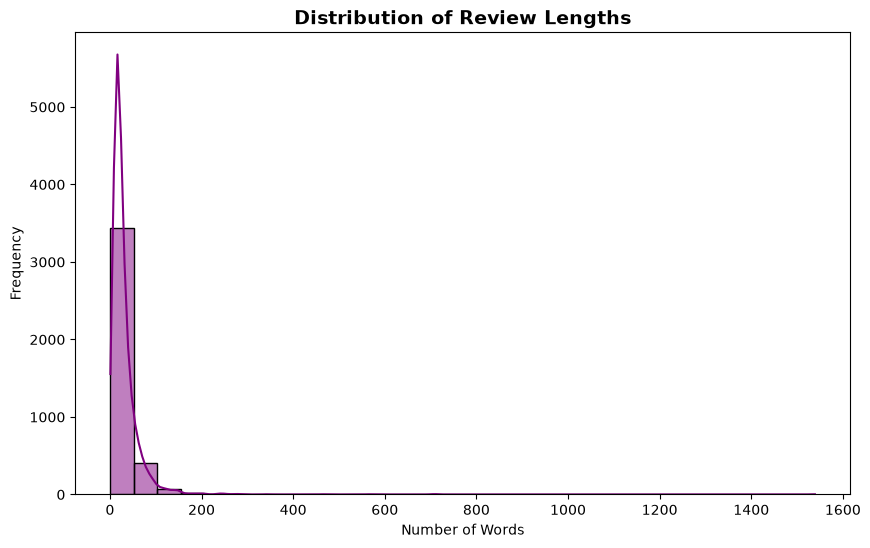

In [49]:
plt.figure(figsize=(10,6))

sns.histplot(
    train_df["review_length"],
    bins=30,
    kde=True,
    color="purple"
)

plt.title("Distribution of Review Lengths", fontsize=14, fontweight="bold")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")

plt.show()

### Observation

The histogram shows the distribution of review lengths across the dataset. Most reviews are concentrated within a specific word range, while a few exceptionally long reviews appear as outliers.

Understanding review length distribution helps in selecting appropriate text preprocessing and feature engineering techniques for NLP models.

## Average Review Length by Sentiment

In [50]:
avg_length = train_df.groupby("sentiment")["review_length"].mean().sort_values(ascending=False)

avg_length

sentiment
Negative    50.644444
Neutral     36.525316
Positive    29.915539
Name: review_length, dtype: float64

### Observation

This analysis compares the average review length across different sentiment categories.

Review length may vary depending on customer satisfaction levels. Customers expressing strong positive or negative opinions often provide more detailed feedback compared to neutral reviews.

Understanding this relationship can provide additional insights into customer behavior and review-writing patterns.

## Average Review Length Visualization

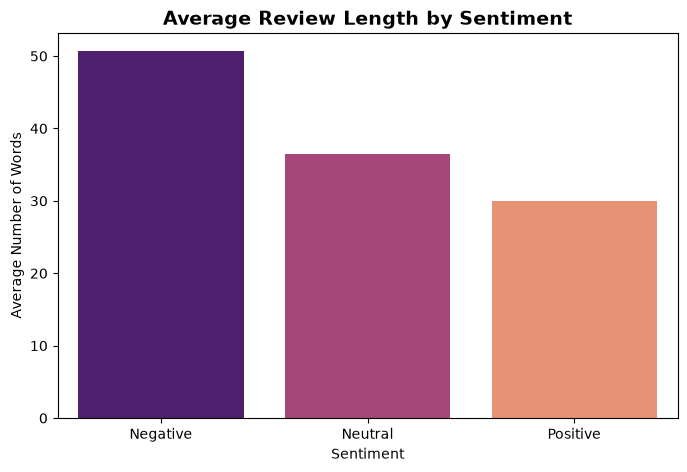

In [51]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=avg_length.index,
    y=avg_length.values,
    palette="magma"
)

plt.title("Average Review Length by Sentiment", fontsize=14, fontweight="bold")
plt.xlabel("Sentiment")
plt.ylabel("Average Number of Words")

plt.show()

### Observation

The visualization shows how review lengths differ across sentiment categories.

Sentiment groups with longer average reviews indicate customers tend to provide more detailed explanations of their experiences. This information can be valuable when designing sentiment analysis models and understanding customer engagement.

## Top 20 Most Frequent Words Analysis

In [52]:
from collections import Counter

all_words = " ".join(train_df["reviews.text"].astype(str)).lower().split()

word_freq = Counter(all_words)

top_words = pd.DataFrame(
    word_freq.most_common(20),
    columns=["Word", "Frequency"]
)

top_words

,Word,Frequency
0,the,5258
1,and,3915
2,to,3915
3,i,3505
4,it,2898
5,for,2873
6,a,2682
7,is,2377
8,my,2223
9,this,1988


### Observation

This analysis identifies the most frequently occurring words in customer reviews.

Frequently appearing words provide insights into common topics, product features, and customer experiences discussed throughout the dataset. These words help reveal the dominant themes present in customer feedback.

## Top 20 Most Frequent Words Visualization

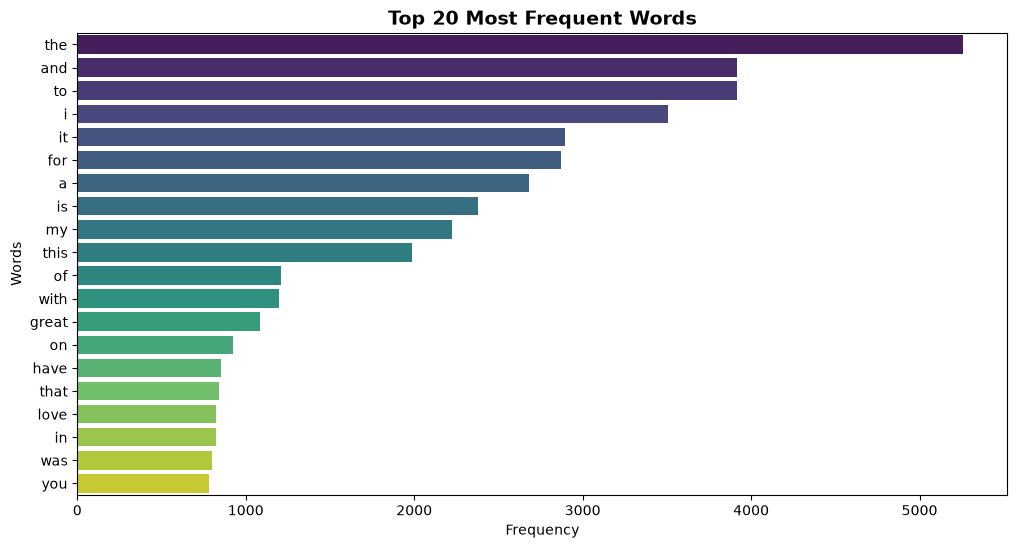

In [53]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=top_words,
    x="Frequency",
    y="Word",
    palette="viridis"
)

plt.title("Top 20 Most Frequent Words", fontsize=14, fontweight="bold")
plt.xlabel("Frequency")
plt.ylabel("Words")

plt.show()

### Observation

The bar chart highlights the most commonly used words across customer reviews.

These words represent frequently discussed topics and product characteristics. Further text preprocessing, such as removing stopwords and punctuation, may provide more meaningful insights into customer sentiment and product-related discussions.

## Text Cleaning and Stopword Removal

In [54]:
from nltk.corpus import stopwords
import re

stop_words = set(stopwords.words("english"))

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    words = [
        word for word in text.split()
        if word not in stop_words
    ]

    return " ".join(words)

train_df["cleaned_review"] = train_df["reviews.text"].apply(clean_text)

train_df[["reviews.text", "cleaned_review"]].head()

,reviews.text,cleaned_review
0,Purchased on Black FridayPros - Great Price (e...,purchased black fridaypros great price even sa...
1,I purchased two Amazon in Echo Plus and two do...,purchased two amazon echo plus two dots plus f...
2,Just an average Alexa option. Does show a few ...,average alexa option show things screen still ...
3,"very good product. Exactly what I wanted, and ...",good product exactly wanted good price
4,This is the 3rd one I've purchased. I've bough...,rd one ive purchased ive bought one nieces cas...


### Observation

Text preprocessing removes punctuation, special characters, and common stopwords that do not contribute significantly to sentiment understanding.

The cleaned text retains meaningful words while reducing noise, making subsequent NLP analyses such as word frequency and word cloud generation more informative.

# Word Cloud Visualization

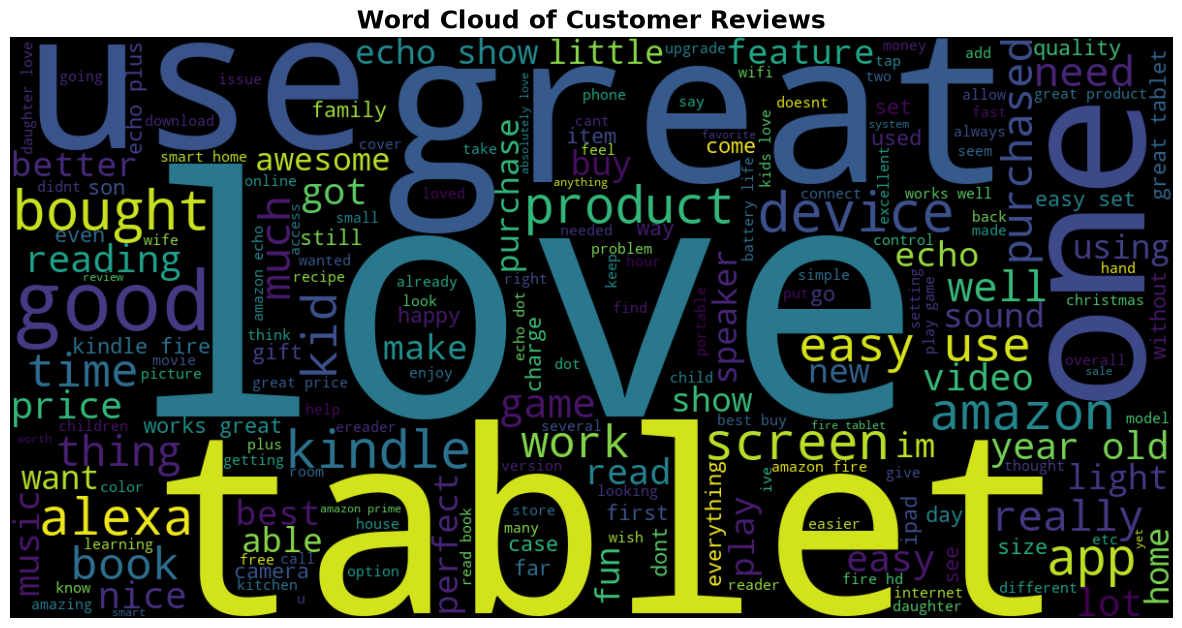

In [55]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

all_words = " ".join(train_df["cleaned_review"])

wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color="black",
    colormap="viridis"
).generate(all_words)

plt.figure(figsize=(15,8))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud of Customer Reviews",
          fontsize=18,
          fontweight="bold")
plt.show()

## Observation

The word cloud highlights the most frequently occurring words in customer reviews.

Larger words indicate higher frequency and represent common themes discussed by customers. This visualization provides a quick overview of important terms present in the review dataset and helps identify major topics influencing customer sentiment.

# Positive Reviews Word Cloud

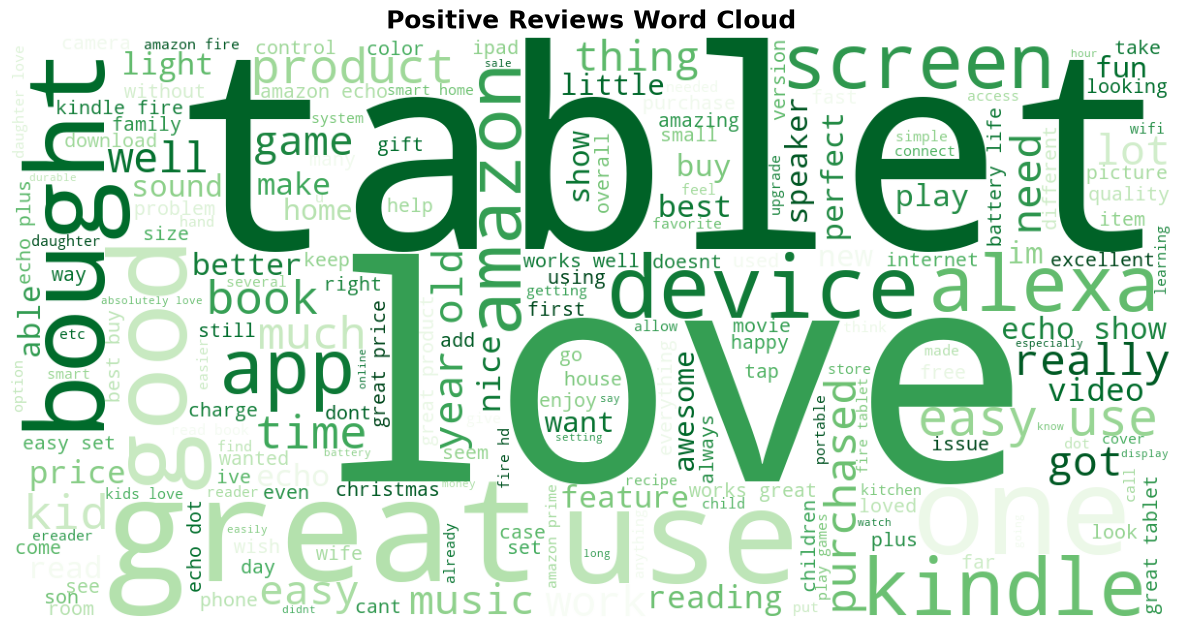

In [56]:
positive_text = " ".join(
    train_df[train_df["sentiment"]=="Positive"]["cleaned_review"]
)

wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color="white",
    colormap="Greens"
).generate(positive_text)

plt.figure(figsize=(15,8))
plt.imshow(wordcloud)
plt.axis("off")
plt.title("Positive Reviews Word Cloud",
          fontsize=18,
          fontweight="bold")
plt.show()

## Observation

The positive review word cloud displays the most common words used by satisfied customers.

Frequently appearing terms represent product strengths, customer satisfaction factors, and positive experiences. These words help identify key features appreciated by customers.

# Neutral Reviews Word Cloud

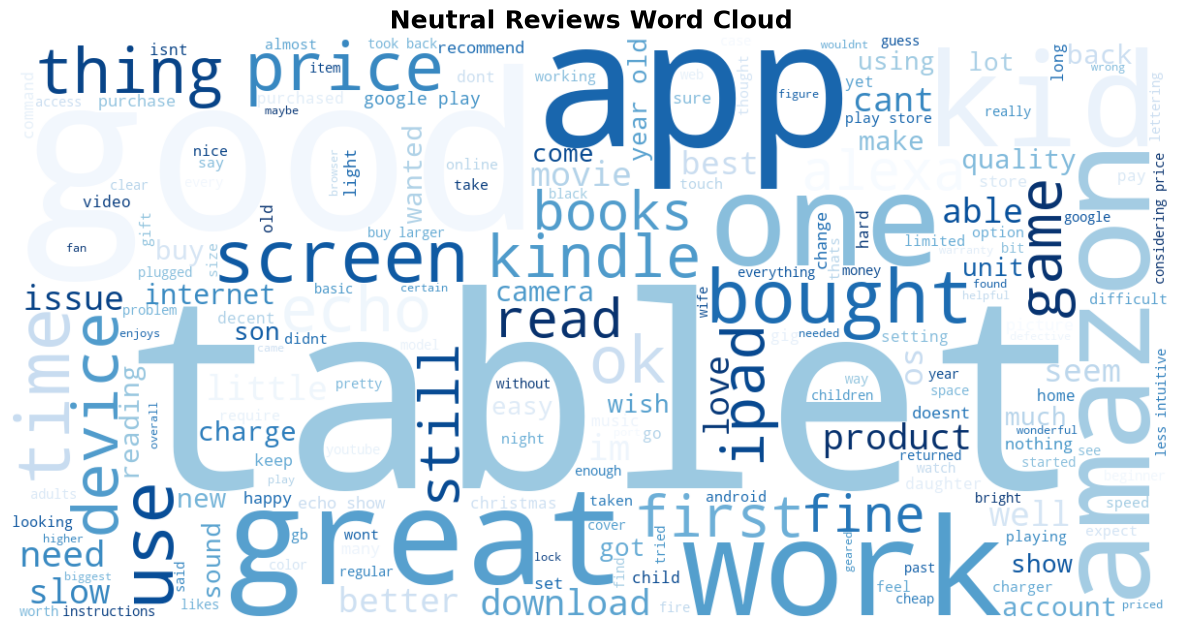

In [57]:
neutral_text = " ".join(
    train_df[train_df["sentiment"] == "Neutral"]["cleaned_review"]
)

wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color="white",
    colormap="Blues"
).generate(neutral_text)

plt.figure(figsize=(15,8))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title(
    "Neutral Reviews Word Cloud",
    fontsize=18,
    fontweight="bold"
)
plt.show()

## Observation

The neutral review word cloud highlights words commonly used in reviews expressing balanced or average opinions.

These reviews often contain descriptive terms rather than strong positive or negative sentiments, providing insight into customer expectations and product usability.

# Negative Reviews Word Cloud

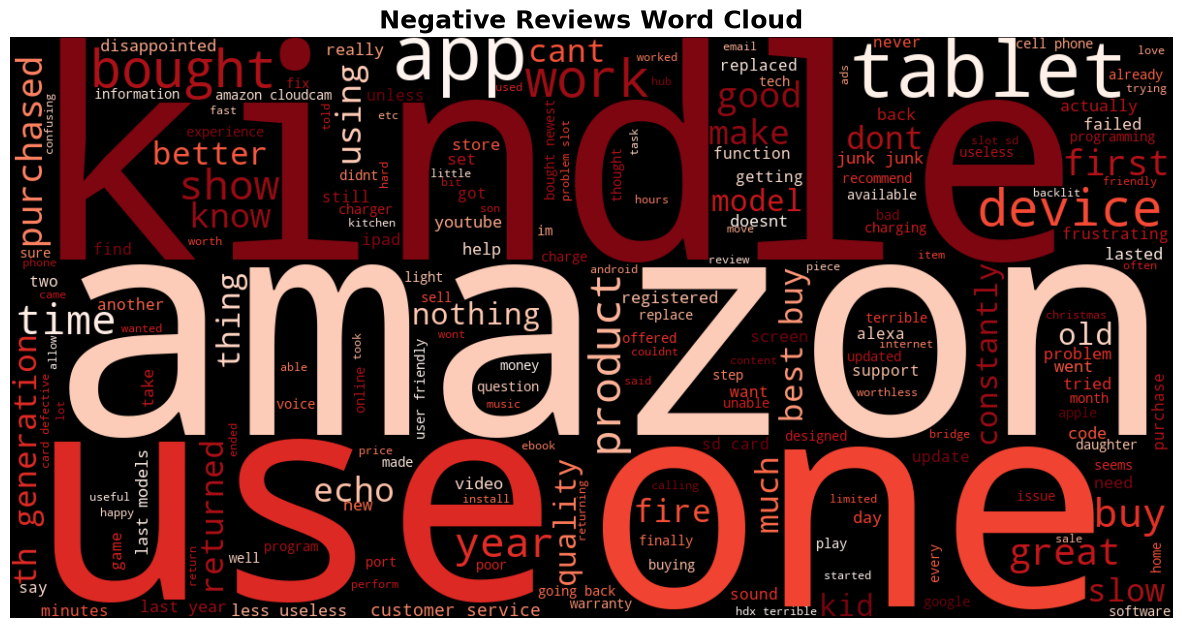

In [58]:
negative_text = " ".join(
    train_df[train_df["sentiment"] == "Negative"]["cleaned_review"]
)

wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color="black",
    colormap="Reds"
).generate(negative_text)

plt.figure(figsize=(15,8))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title(
    "Negative Reviews Word Cloud",
    fontsize=18,
    fontweight="bold"
)
plt.show()

## Observation

The negative review word cloud displays the most frequent words associated with customer dissatisfaction.

These words help identify recurring issues, complaints, and areas where products may not meet customer expectations. Such insights are valuable for improving product quality and customer experience.

# EDA Summary

## Observation

The exploratory data analysis reveals that the dataset is largely clean, with very few missing values and a small number of duplicate records.

Sentiment distribution is highly imbalanced, with Positive reviews dominating the dataset. Review length analysis indicates that customers generally provide concise feedback, while a few reviews contain extensive descriptions.

Word frequency analysis and word clouds highlight the most common themes discussed by customers. Positive reviews focus on product satisfaction and usability, while negative reviews emphasize issues and limitations.

These findings provide a strong foundation for the next stage of the project, which involves text vectorization, feature engineering, model training, and sentiment classification.